# Credit Card Customer Segmentation

## Business Problem

Credit card companies have thousands of customers with different spending behaviors.

Treating all customers equally leads to:

- Inefficient marketing campaigns
- Poor customer retention
- Low customer satisfaction

The goal of this project is to segment customers into meaningful groups using unsupervised machine learning techniques.

The identified clusters can help the business:

- Create targeted marketing campaigns
- Improve customer retention
- Design personalized offers
- Better understand customer behavior

## Dataset Features Description

The dataset contains credit card customer behavior information. Each row represents a unique customer, and the columns describe different aspects of their credit card usage, spending habits, payment behavior, and account activity.

| Feature | Description |
|----------|-------------|
| CUST_ID | Unique identifier assigned to each customer. Used only for identification and not for analysis. |
| BALANCE | Current balance amount remaining in the customer's account. |
| BALANCE_FREQUENCY | Frequency at which the balance is updated (value between 0 and 1, where 1 indicates frequent updates). |
| PURCHASES | Total amount spent on purchases made using the credit card. |
| ONEOFF_PURCHASES | Amount spent on one-time purchases. |
| INSTALLMENTS_PURCHASES | Amount spent through installment-based purchases. |
| CASH_ADVANCE | Total cash withdrawn using the credit card. |
| PURCHASES_FREQUENCY | Frequency of purchase transactions (0 to 1). Higher values indicate more frequent purchases. |
| ONEOFF_PURCHASES_FREQUENCY | Frequency of one-time purchases. |
| PURCHASES_INSTALLMENTS_FREQUENCY | Frequency of installment purchases. |
| CASH_ADVANCE_FREQUENCY | Frequency of cash advance transactions. |
| CASH_ADVANCE_TRX | Number of cash advance transactions performed by the customer. |
| PURCHASES_TRX | Total number of purchase transactions. |
| CREDIT_LIMIT | Maximum credit amount available to the customer. |
| PAYMENTS | Total amount paid by the customer. |
| MINIMUM_PAYMENTS | Minimum payment amount made by the customer. |
| PRC_FULL_PAYMENT | Percentage of months in which the customer paid the full balance. |
| TENURE | Number of months the customer has held the credit card account. |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

# EDA

In [2]:
df = pd.read_csv("C:/Users/Dell/OneDrive/Desktop/Unsupervised Learning/Data/raw/CC GENERAL.csv")

In [3]:
df.head(5)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
df.shape

(8950, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [6]:
df.describe().round(2)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8949.00,8950.00,8637.00,8950.00,8950.00
mean,1564.47,0.88,1003.20,592.44,411.07,978.87,0.49,0.20,0.36,0.14,3.25,14.71,4494.45,1733.14,864.21,0.15,11.52
std,2081.53,0.24,2136.63,1659.89,904.34,2097.16,0.40,0.30,0.40,0.20,6.82,24.86,3638.82,2895.06,2372.45,0.29,1.34
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,50.00,0.00,0.02,0.00,6.00
25%,128.28,0.89,39.64,0.00,0.00,0.00,0.08,0.00,0.00,0.00,0.00,1.00,1600.00,383.28,169.12,0.00,12.00
50%,873.39,1.00,361.28,38.00,89.00,0.00,0.50,0.08,0.17,0.00,0.00,7.00,3000.00,856.90,312.34,0.00,12.00
75%,2054.14,1.00,1110.13,577.40,468.64,1113.82,0.92,0.30,0.75,0.22,4.00,17.00,6500.00,1901.13,825.49,0.14,12.00
max,19043.14,1.00,49039.57,40761.25,22500.00,47137.21,1.00,1.00,1.00,1.50,123.00,358.00,30000.00,50721.48,76406.21,1.00,12.00


In [7]:
df.isnull().sum().sort_values(ascending=False)

MINIMUM_PAYMENTS                    313
CREDIT_LIMIT                          1
CUST_ID                               0
BALANCE                               0
PRC_FULL_PAYMENT                      0
PAYMENTS                              0
PURCHASES_TRX                         0
CASH_ADVANCE_TRX                      0
CASH_ADVANCE_FREQUENCY                0
PURCHASES_INSTALLMENTS_FREQUENCY      0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_FREQUENCY                   0
CASH_ADVANCE                          0
INSTALLMENTS_PURCHASES                0
ONEOFF_PURCHASES                      0
PURCHASES                             0
BALANCE_FREQUENCY                     0
TENURE                                0
dtype: int64

### Key Insight

- Only **3.5%** of the records have missing values in `MINIMUM_PAYMENTS`.
- `CREDIT_LIMIT` contains only **one missing value**, representing a negligible portion of the dataset.
- The dataset demonstrates high data completeness, reducing the risk of information loss during preprocessing

Since clustering algorithms cannot handle missing values directly, these observations will be addressed during the preprocessing stage. Given the low proportion of missing data, imputation is preferred over removing records to preserve valuable customer information.

In [8]:
df.duplicated().sum()

np.int64(0)

## Customer Spending Analysis
These variables describe how customers spend using their credit cards.

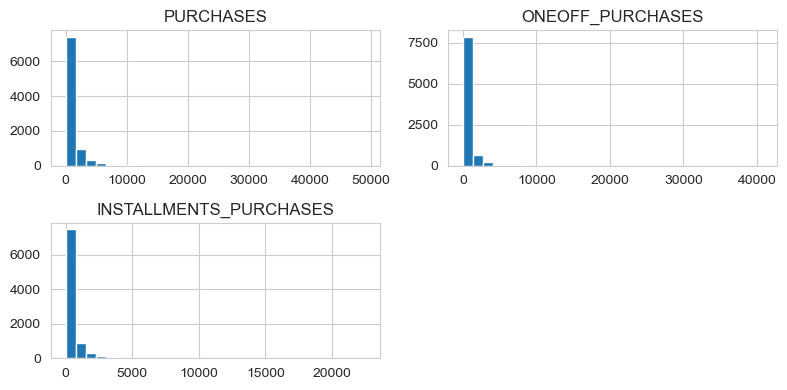

In [9]:
purchase_cols = [
    "PURCHASES",
    "ONEOFF_PURCHASES",
    "INSTALLMENTS_PURCHASES"
]

df[purchase_cols].hist(
    figsize=(8,4),
    bins=30
)

plt.tight_layout()
plt.show()

The distributions are highly right-skewed.

Most customers spend relatively small amounts, while a smaller group of customers exhibits substantially higher spending behavior.

This suggests the existence of potential high-value customer segments.

## Credit Usage Analysis

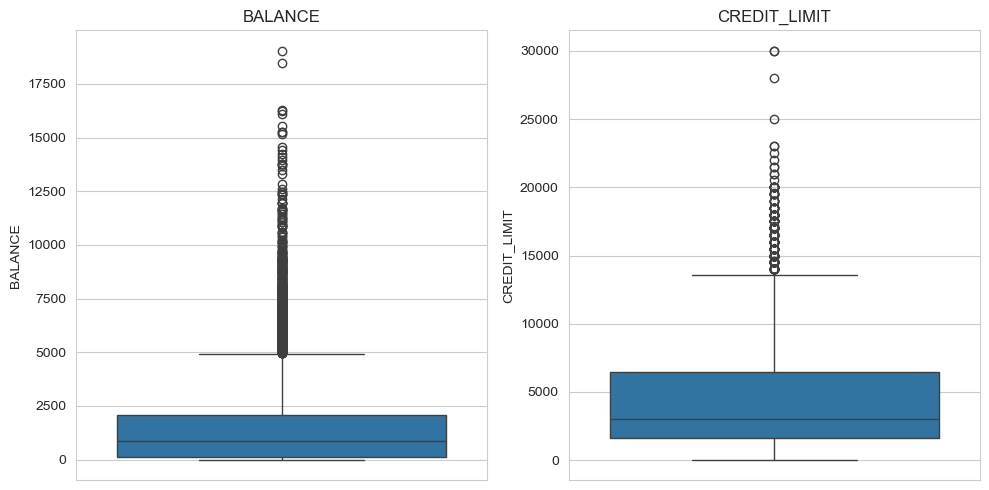

In [10]:
credit_cols = [
    "BALANCE",
    "CREDIT_LIMIT"
]

plt.figure(figsize=(10,5))

for i,col in enumerate(credit_cols,1):
    plt.subplot(1,2,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

\
Large variability exists in both account balances and credit limits.

This indicates that customers differ significantly in their credit usage patterns and financial capacity.

## Payment Behavior Analysis

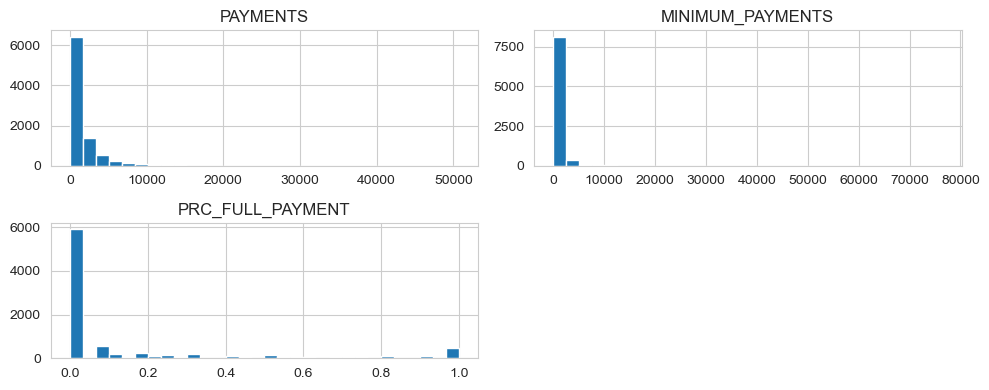

In [11]:
payment_cols = [
    "PAYMENTS",
    "MINIMUM_PAYMENTS",
    "PRC_FULL_PAYMENT"
]

df[payment_cols].hist(
    figsize=(10,4),
    bins=30
)

plt.tight_layout()

Some customers paid tens of thousands, while the majority paid much less..

Very few customers have exceptionally high minimum payment amounts.

Most customers rarely pay their full balance..

## Outliers

In [12]:
num_cols = df.select_dtypes(include='number').columns

In [13]:
def outlier_percentage(series):

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = series[
        (series < lower) |
        (series > upper)
    ]

    return round(
        len(outliers) / len(series) * 100,
        2
    )

outlier_summary = pd.DataFrame({
    "Feature": num_cols,
    "Outlier_%": [
        outlier_percentage(df[col])
        for col in num_cols
    ]
})

outlier_summary.sort_values(
    "Outlier_%",
    ascending=False
)

,Feature,Outlier_%
1,BALANCE_FREQUENCY,16.68
15,PRC_FULL_PAYMENT,16.47
16,TENURE,15.26
5,CASH_ADVANCE,11.51
3,ONEOFF_PURCHASES,11.32
4,INSTALLMENTS_PURCHASES,9.69
14,MINIMUM_PAYMENTS,9.40
13,PAYMENTS,9.03
2,PURCHASES,9.03
10,CASH_ADVANCE_TRX,8.98


Several outliers were identified, particularly in monetary variables. Since these values may represent genuine customer behavior rather than errors, they will not be removed during EDA.

During preprocessing, appropriate transformations and scaling techniques will be applied to reduce their impact. Additional outlier treatment will only be considered if clustering performance is negatively affected.

## Correlation Heatmap

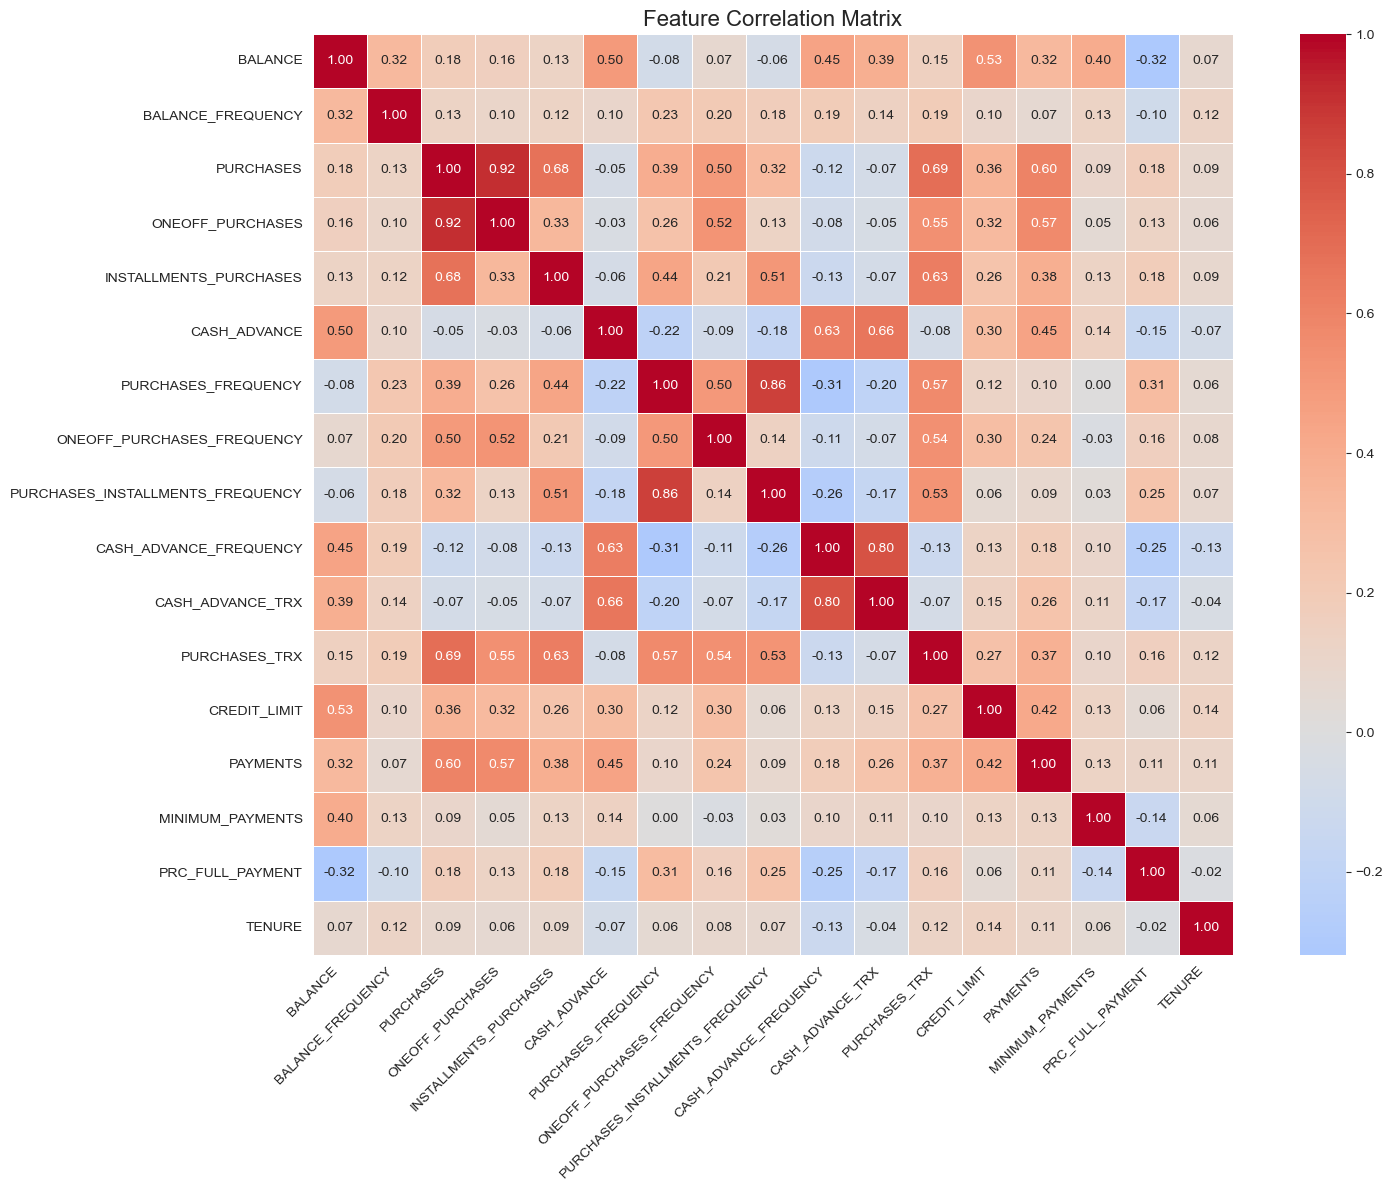

In [14]:
plt.figure(figsize=(16,12))

corr = df.drop(columns=["CUST_ID"]).corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)

plt.title("Feature Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Several variables exhibit moderate to strong positive correlations, indicating that certain aspects of customer behavior are closely related. For example, customers with higher purchase activity generally tend to make higher payments, while customers with larger credit limits often maintain higher balances.

These relationships suggest the presence of overlapping information within the dataset and provide justification for applying dimensionality reduction techniques such as PCA during feature engineering.

## Purchases vs Payments

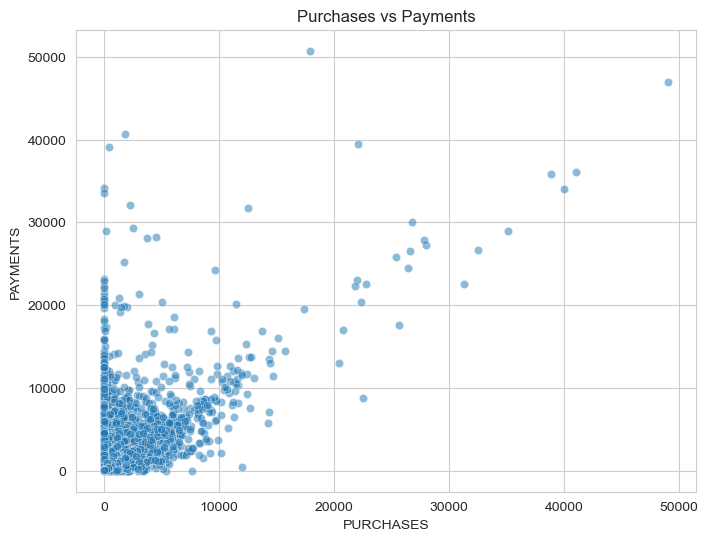

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df,
                x="PURCHASES",
                y="PAYMENTS",
                alpha=0.5
               )
plt.title("Purchases vs Payments")
plt.show()
            

A positive relationship is observed between purchase amounts and payment amounts.

Customers with higher spending activity generally tend to make larger payments.

This suggests that many high-spending customers are also actively repaying their balances. These customers may represent financially active and valuable customer segments.

## Credit Limit VS Balance

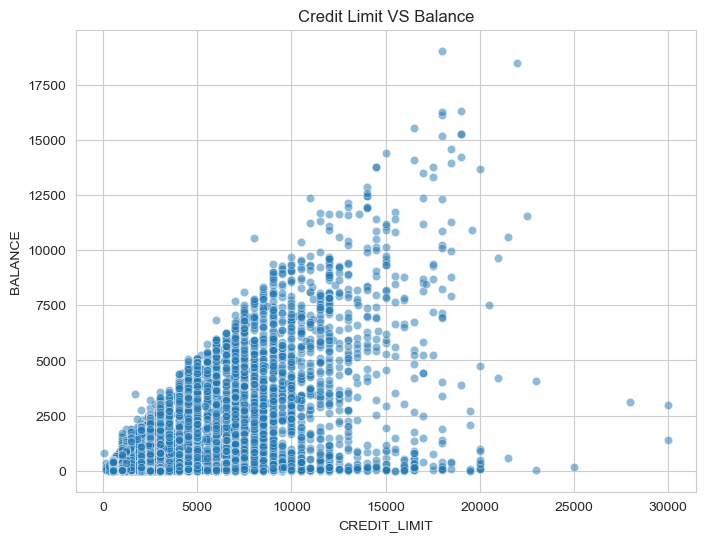

In [16]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,
                x='CREDIT_LIMIT',
                y='BALANCE',
                alpha=0.5
               )
plt.title("Credit Limit VS Balance")
plt.show()


Customers with larger credit limits generally tend to maintain higher account balances.

However, significant variation exists within the relationship, indicating different credit usage patterns among customers.

Some customers utilize a large portion of their available credit, while others maintain relatively low balances despite having high credit limits.

This behavior may help distinguish different customer segments during clustering.

## Cash Advance Amount vs Transactions

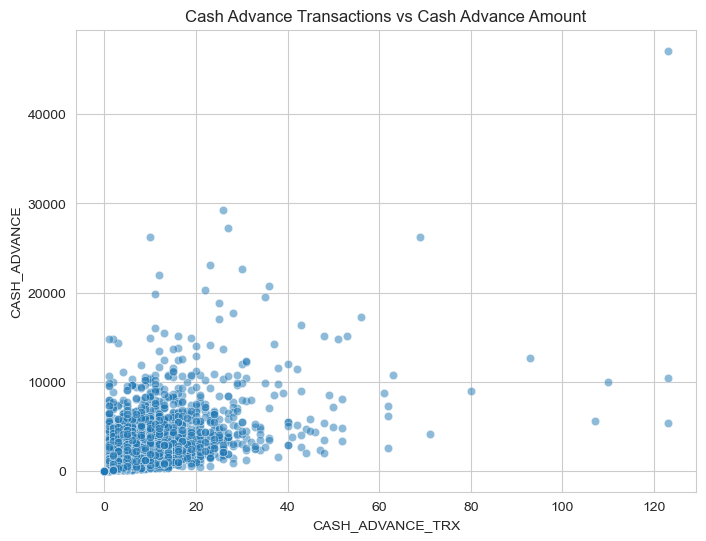

In [17]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df,
                x='CASH_ADVANCE_TRX',
                y='CASH_ADVANCE',
                alpha=0.5
               )
plt.title("Cash Advance Transactions vs Cash Advance Amount")
plt.show()

A positive relationship exists between the number of cash advance transactions and the total cash advance amount.

Customers who perform more cash advance transactions generally withdraw larger amounts of cash.

Frequent cash advance usage may indicate customers who rely more heavily on short-term credit facilities.

This behavior could form a distinct customer segment with unique financial characteristics.

## Skweness Analysis

In [18]:
df_no_id = df.drop(columns=['CUST_ID'])

skewness = df_no_id.skew().sort_values(ascending=False)
skewness[skewness > 1]

MINIMUM_PAYMENTS              13.622797
ONEOFF_PURCHASES              10.045083
PURCHASES                      8.144269
INSTALLMENTS_PURCHASES         7.299120
PAYMENTS                       5.907620
CASH_ADVANCE_TRX               5.721298
CASH_ADVANCE                   5.166609
PURCHASES_TRX                  4.630655
BALANCE                        2.393386
PRC_FULL_PAYMENT               1.942820
CASH_ADVANCE_FREQUENCY         1.828686
ONEOFF_PURCHASES_FREQUENCY     1.535613
CREDIT_LIMIT                   1.522464
dtype: float64

### Skewness Analysis

Skewness statistics revealed that several variables exhibit extremely right-skewed distributions, particularly monetary and transaction-based features.

The highest skewness values were observed in:

- MINIMUM_PAYMENTS
- ONEOFF_PURCHASES
- PURCHASES
- INSTALLMENTS_PURCHASES
- PAYMENTS
- CASH_ADVANCE

These results indicate that a small number of customers account for exceptionally large spending, payment, and cash advance amounts.

To reduce the influence of extreme values while preserving meaningful customer behavior, logarithmic transformation will be applied to highly skewed monetary and transaction variables during preprocessing.

Frequency-based variables will remain unchanged because they are naturally bounded between 0 and 1.

# EDA Summary

## Key Findings

1. The dataset contains customer-level credit card behavior information.
2. Missing values are present and will require treatment.
3. Several features exhibit highly skewed distributions.
4. Significant outliers are present in financial variables.
5. Strong correlations exist among some features.

## Recommendations for Next Phase

1. Remove non-informative identifier columns.
2. Handle missing values appropriately.
3. Scale numerical features.
4. Engineer behavior-based features.
5. Apply dimensionality reduction where necessary.

# Preprocessing & Feature Engineering

### Feature Engineering

Raw financial variables do not always capture customer behavior effectively. Therefore, additional behavioral features were created to better represent spending habits, credit utilization, and repayment patterns.

The following features were engineered:

- **UTILIZATION_RATIO**: Measures the proportion of available credit currently being used.
- **AVG_PURCHASE_VALUE**: Represents the average amount spent per purchase transaction.
- **PAYMENT_RATIO**: Captures the relationship between customer payments and outstanding balances.

These features provide more meaningful behavioral insights and are expected to improve the quality of customer segmentation.

### Preprocessing Pipeline

A preprocessing pipeline was implemented to ensure that all data preparation steps are applied consistently and in the correct order.

The pipeline performs:

1. Removal of irrelevant variables
2. Missing value imputation
3. Feature engineering
4. Logarithmic transformation of skewed variables
5. Feature standardization

Using a pipeline improves reproducibility, maintainability, and ensures that preprocessing is applied consistently across all clustering experiments.

In [19]:
import sys
sys.path.append(r"C:/Users/Dell/OneDrive/Desktop/Unsupervised Learning")

In [20]:
from src.pipeline import preprocessing_pipeline
print(preprocessing_pipeline)
X_processed = preprocessing_pipeline.fit_transform(df)

print(type(X_processed))
print(X_processed.shape)

Pipeline(steps=[('remove_id', RemoveCustomerID()), ('imputer', MedianImputer()),
                ('feature_engineering', FeatureEngineer()),
                ('log_transform', LogTransformer()),
                ('scaler', StandardScaler())])
<class 'numpy.ndarray'>
(8950, 20)


### Pipeline Validation

The preprocessing pipeline was executed successfully on the complete dataset.

The resulting processed dataset contains:

* **8,950 observations** (customers)
* **20 features**

The increase in feature count is due to the creation of three additional behavioral features:

* UTILIZATION_RATIO
* AVG_PURCHASE_VALUE
* PAYMENT_RATIO

The final output is a standardized numerical matrix suitable for dimensionality reduction and clustering algorithms.


In [21]:
feature_names = [
    'BALANCE',
    'BALANCE_FREQUENCY',
    'PURCHASES',
    'ONEOFF_PURCHASES',
    'INSTALLMENTS_PURCHASES',
    'CASH_ADVANCE',
    'PURCHASES_FREQUENCY',
    'ONEOFF_PURCHASES_FREQUENCY',
    'PURCHASES_INSTALLMENTS_FREQUENCY',
    'CASH_ADVANCE_FREQUENCY',
    'CASH_ADVANCE_TRX',
    'PURCHASES_TRX',
    'CREDIT_LIMIT',
    'PAYMENTS',
    'MINIMUM_PAYMENTS',
    'PRC_FULL_PAYMENT',
    'TENURE',
    'UTILIZATION_RATIO',
    'AVG_PURCHASE_VALUE',
    'PAYMENT_RATIO'
]

X_processed_df = pd.DataFrame(
    X_processed,
    columns=feature_names
)

X_processed_df.to_csv(
    "C:/Users/Dell/OneDrive/Desktop/Unsupervised Learning/Data/processed/preprocessed_data.csv",
    index=False
)

## Dimentionality Reduction (PCA)

In [22]:
# Finding number of components needed to get 95% of information

from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_processed)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
cumulative_variance

array([0.29965811, 0.49951344, 0.58991048, 0.66143925, 0.72009197,
       0.77236864, 0.81676736, 0.85934607, 0.89386026, 0.91914989,
       0.94311408, 0.95522208, 0.9663734 , 0.97691776, 0.98411985,
       0.98990491, 0.99435226, 0.99657945, 0.9986154 , 1.        ])

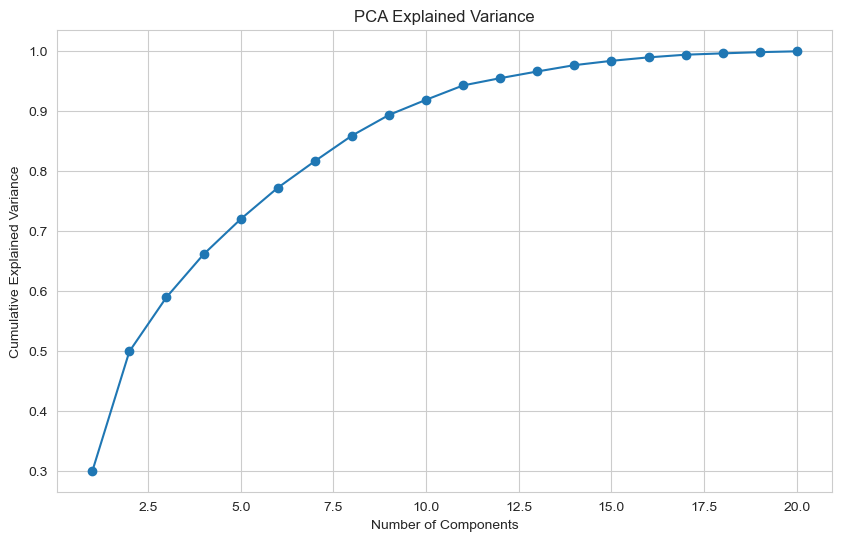

In [23]:
plt.figure(figsize=(10,6))

plt.plot(
    range(
        1,
        len(cumulative_variance)+1
    ),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title(
    "PCA Explained Variance"
)

plt.grid(True)

plt.show()

This cumulative explained variance plot was used to determine the optimal number of principal components.

The analysis showed that:

* 10 components retain approximately 92% of the total variance.
* 12 components retain approximately 95% of the total variance.

A threshold of 95% explained variance was selected to preserve the majority of the information contained in the original dataset while reducing dimensionality.

Therefore, 12 principal components were retained for subsequent clustering analysis.


In [24]:
from src.pipeline import pca_pipeline
print(pca_pipeline)
X_pca = pca_pipeline.fit_transform(df)
print(X_pca.shape)

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('remove_id', RemoveCustomerID()),
                                 ('imputer', MedianImputer()),
                                 ('feature_engineering', FeatureEngineer()),
                                 ('log_transform', LogTransformer()),
                                 ('scaler', StandardScaler())])),
                ('pca', PCA(n_components=0.95))])
(8950, 12)


the feature space was reduced from 20 variables to 12 principal components while maintaining most of the information required for customer segmentation.

The transformed dataset was saved for use in subsequent clustering analysis.

In [25]:
# saving pca pipeline

import joblib

joblib.dump(pca_pipeline,
           "C:/Users/Dell/OneDrive/Desktop/Unsupervised Learning/models/pca_pipeline.pkl")

['C:/Users/Dell/OneDrive/Desktop/Unsupervised Learning/models/pca_pipeline.pkl']

# Modeling

To identify meaningful customer segments, two clustering algorithms will be evaluated:

1. K-Means Clustering
2. Hierarchical Clustering

For K-Means, the optimal number of clusters will be determined using the Elbow Method and Silhouette Score. Hierarchical Clustering will be evaluated using a dendrogram and Silhouette Score.

The performance of both algorithms will be compared, and the most suitable clustering solution will be selected based on cluster quality and business interpretability.

In [26]:
import seaborn as sns
from src.clustering import evaluate_kmeans

## Evaluating KMeans Clustering

In [27]:
kmeans_result = evaluate_kmeans(X_pca)
kmeans_result

,K,WCSS,Silhouette
0,2,130413.009696,0.250486
1,3,111400.855283,0.232528
2,4,102210.193373,0.207784
3,5,93422.400357,0.217102
4,6,86707.938407,0.220809
5,7,80487.861757,0.222972
6,8,77435.241005,0.221939
7,9,72923.578406,0.179236
8,10,69683.443490,0.184926


### Elbow Method

<Axes: xlabel='K'>

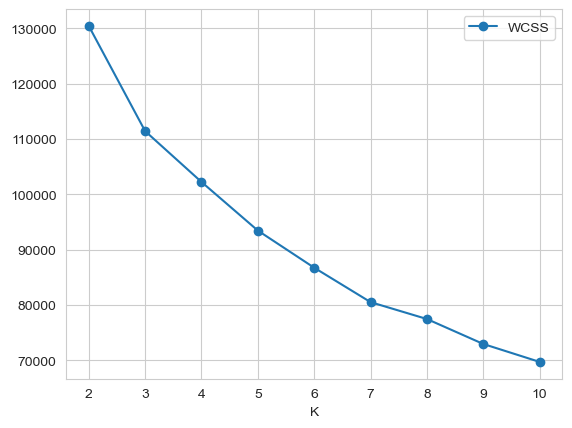

In [28]:
kmeans_result.plot(
    x="K",
    y="WCSS",
    marker="o"
)

### Silhouette Analysis

<Axes: xlabel='K'>

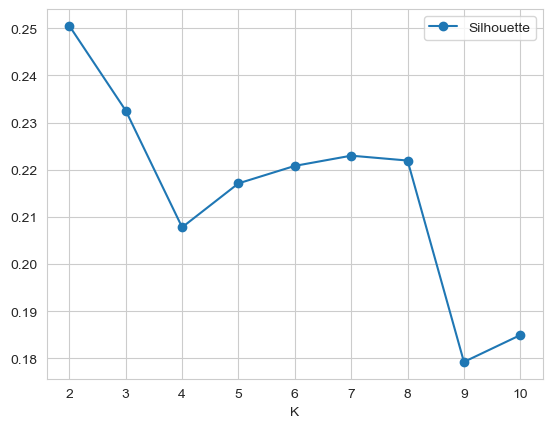

In [29]:
kmeans_result.plot(
    x="K",
    y="Silhouette",
    marker="o"
)

 Choosing $k = 7$ over $k = 2$

While $k = 2$ achieves the highest global silhouette score, **$k = 7$ is the optimal choice** for practical segmentation. It provides the best balance between geometric separation, variance explanation, and granular utility.

### 1. Key Metrics Comparison

| Metric | $k = 2$ | $k = 7$ | Decision Rationale |
| :--- | :---: | :---: | :--- |
| **Silhouette Score** | **0.2505** *(Global Max)* | **0.2230** *(Local Max)* | $k = 2$ wins marginally (+12%), but only because it splits data into two massive, heterogeneous blobs. Among granular options ($k \ge 5$), $k = 7$ is the clear peak. |
| **WCSS (Inertia)** | High *(Steep slope)* | **Elbow Point** | $k = 2$ leaves too much variance unexplained. $k = 7$ represents the mathematical inflection point—moving to $k = 8$ cuts the WCSS reward by half (from $-6,220$ down to $-2,948$). |
| **Actionability** | Too Coarse | **Highly Actionable** | $k = 2$ over-merges and collapses distinct sub-groups. $k = 7$ captures the nuanced variation required for targeted domain strategies. |

### 2. Core Differences At-a-Glance

* **Why not $k = 2$?** It trades away necessary resolution for a minor geometric gain. WCSS remains ~13% higher than at $k = 7$, meaning it fails to parsimoniously model the data's internal structure.
* **Why $k = 7$?** It sits exactly at the WCSS elbow, maximizes separation for complex granular clustering, and minimizes the risk of overfitting to noise.

> **Verdict:** **Select $k = 7$.** It delivers an interpretable, multi-segment breakdown without sacrificing mathematical defensibility. Prefer $k = 2$ only if the business task strictly mandates a binary partition.

### Training KMeans


In [30]:
from src.clustering import train_kmeans

kmeans_model,kmeans_labels = train_kmeans(X_pca,n_clusters=7)

In [31]:
df_clustered = df.copy()
df_clustered["CLUSTER"] = kmeans_labels
df_clustered.head(5)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,CLUSTER
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,1
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,0
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,3
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12,5
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,5


In [32]:
cluster_distribution = (
    df_clustered["CLUSTER"]
    .value_counts()
    .sort_index()
)

cluster_distribution

CLUSTER
0    2187
1    1044
2    1661
3    1459
4    1264
5    1330
6       5
Name: count, dtype: int64

### Cluster Distribution Assessment

The initial 7-cluster solution produced one cluster containing only 5 observations. Such a small cluster is unlikely to represent a meaningful customer segment and may instead indicate the presence of extreme customer behavior or outliers.

To ensure the resulting customer segments are interpretable and actionable, alternative cluster solutions were further evaluated.

In [33]:
kmeans_model,kmeans_labels = train_kmeans(X_pca,n_clusters=6)

In [48]:
df_clustered = X_processed_df.copy()
df_clustered["CLUSTER"] = kmeans_labels
df_clustered.head(5)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,UTILIZATION_RATIO,AVG_PURCHASE_VALUE,PAYMENT_RATIO,CLUSTER
0,-1.205218,-0.249434,-0.113532,-0.987090,0.394480,-0.930733,-0.806490,-0.678661,-0.707313,-0.675349,-0.810069,-0.579510,-1.447163,-0.824484,-0.829841,-0.525551,0.36068,-0.896075,-0.245761,-0.055001,3
1,0.948918,0.134325,-1.679855,-0.987090,-1.087454,1.528788,-1.221758,-0.678661,-0.916995,0.573963,0.784603,-1.379210,0.926060,1.065033,0.908184,0.234227,0.36068,0.177171,-0.542582,-0.072201,2
2,0.824993,0.518084,0.600727,1.062022,-1.087454,-0.930733,1.269843,2.673451,-0.916995,-0.675349,-0.810069,0.487865,1.010229,-0.119300,0.450407,-0.525551,0.36068,-0.144331,0.012553,-0.077220,5
3,0.624653,-1.016953,0.827499,1.265778,-1.087454,0.564372,-1.014125,-0.399319,-0.916995,-0.258913,-0.123281,-0.874655,1.010229,-4.161996,-0.144271,-0.525551,0.36068,-0.428890,6.453240,-0.078433,4
4,0.271260,0.518084,-0.708481,-0.114307,-1.087454,-0.930733,-1.014125,-0.399319,-0.916995,-0.675349,-0.810069,-0.874655,-1.224909,-0.064979,-0.351833,-0.525551,0.36068,0.752817,-0.467910,-0.074402,4


In [49]:
cluster_distribution = (
    df_clustered["CLUSTER"]
    .value_counts()
    .sort_index()
)

cluster_distribution

CLUSTER
0    1665
1    1260
2    2192
3    1044
4    1334
5    1455
Name: count, dtype: int64

## Final Cluster Selection

Although the initial analysis suggested a 7-cluster solution, cluster distribution analysis revealed that one cluster contained only 5 customers. Such a small cluster is unlikely to represent a meaningful customer segment and may instead capture a few extreme observations.

To improve interpretability and segment stability, a 6-cluster solution was evaluated. The resulting clusters were well balanced, with all segments containing a substantial number of customers.

Therefore, the final K-Means model was trained using **6 clusters**, providing a better balance between cluster quality, business interpretability, and segment stability.


## 2D-ScatterPlot

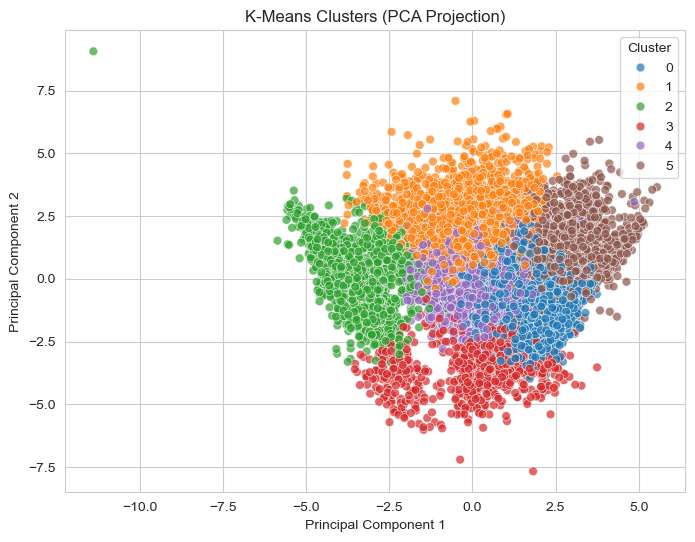

In [36]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=kmeans_labels,
    palette="tab10",
    s=40,
    alpha=0.7
)

plt.title("K-Means Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")

plt.show()

## K-Means Cluster Visualization

The customer segments were visualized using the first two principal components obtained from PCA.

Several clusters exhibit clear separation, indicating that the clustering algorithm successfully identified distinct customer groups. Some overlap between clusters is expected because the visualization represents only two dimensions, while the clustering model was trained on the complete PCA-transformed feature space.

A small number of extreme observations remain visible after preprocessing and PCA. These customers represent highly unusual financial behavior and appear as isolated points in the PCA projection. Since they do not form separate clusters and have minimal impact on the overall segmentation results, they were retained in the analysis.

Overall, the visualization suggests that the six-cluster solution captures meaningful differences in customer behavior while maintaining reasonable cluster separation.

## Evaluating Hierarchical Clustering

In [37]:
from src.clustering import (
    evaluate_hierarchical,
    plot_dendrogram,
    train_hierarchical
)

## Dendrogram

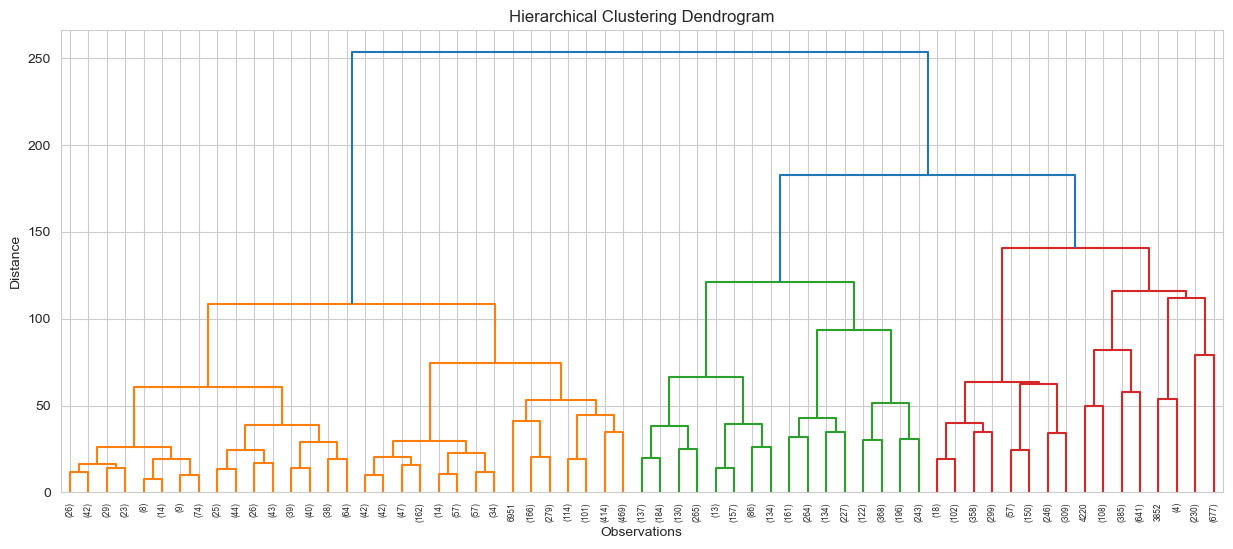

In [38]:
plot_dendrogram(X_pca)

Large vertical jumps were observed at higher linkage distances, indicating natural separation between groups of customers. A horizontal cut around the major distance jumps suggests approximately 5–6 meaningful clusters.

Interestingly, this finding aligns closely with the six-cluster solution obtained from K-Means clustering, providing additional evidence that the selected segmentation structure is reasonable.

In [39]:
hierarchical_result = evaluate_hierarchical(X_pca)
hierarchical_result

,K,Silhouette
0,2,0.206593
1,3,0.169732
2,4,0.159978
3,5,0.153787
4,6,0.166557
5,7,0.168037
6,8,0.175646
7,9,0.174187
8,10,0.173385


## Optimal Cluster Selection
The highest Silhouette Score was achieved at K=2, a two-cluster solution would produce only broad customer categories with limited business value.

Among the higher-cluster solutions, K=8 achieved the highest Silhouette Score (0.176), indicating better cluster separation than K=6, K=7, K=9, and K=10. Furthermore, the Silhouette Score began to stabilize beyond K=8, suggesting that additional clusters provided minimal improvement.

Therefore, **K=8** was selected as the optimal number of clusters for Hierarchical Clustering, balancing clustering quality and customer segmentation granularity.

## Visualizing Hierarchical Model

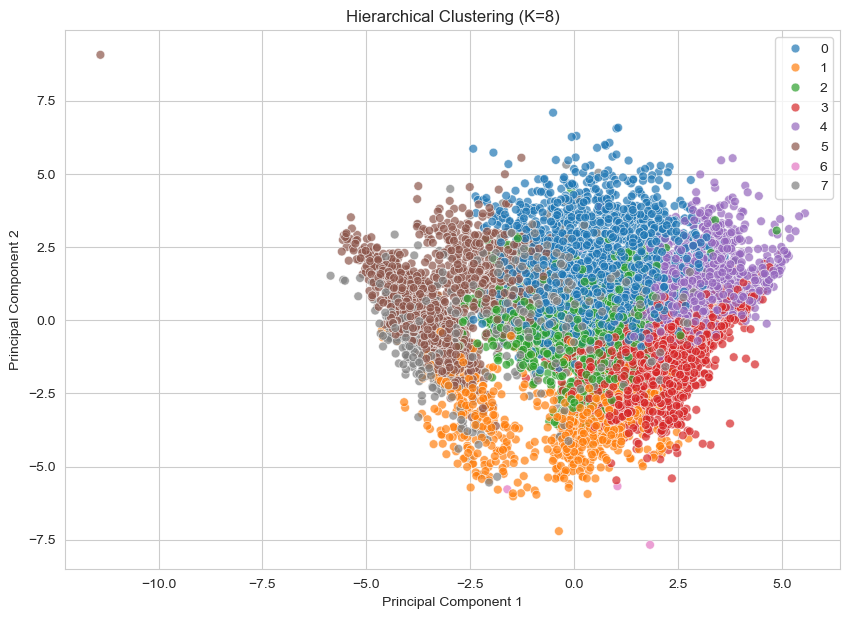

In [40]:
hierarchical_labels = train_hierarchical(X_pca,n_clusters=8)

plt.figure(figsize=(10,7))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=hierarchical_labels,
    palette="tab10",
    s=40,
    alpha=0.7
)

plt.title(
    "Hierarchical Clustering (K=8)"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

The eight-cluster hierarchical solution reveals several customer groups occupying distinct regions of the PCA-transformed feature space. However, a noticeable degree of overlap exists between multiple clusters, particularly in the central region of the projection.

This suggests that while Hierarchical Clustering is able to identify customer segments, the separation between some groups is moderate rather than highly distinct. The observed overlap is consistent with the Silhouette Analysis results, which indicated moderate cluster cohesion and separation.

Overall, the visualization confirms the presence of meaningful customer groupings while highlighting the complexity and gradual transitions that exist in customer financial behavior.

# Model Comparison And Fianl Selection

### Davies–Bouldin Index (DBI)

In [41]:
from sklearn.metrics import davies_bouldin_score

kmeans_dbi = davies_bouldin_score(
    X_pca,
    kmeans_labels
)

print("KMeans DBI:", kmeans_dbi)


hierarchical_dbi = davies_bouldin_score(
    X_pca,
    hierarchical_labels
)

print("Hierarchical DBI:", hierarchical_dbi)

KMeans DBI: 1.5114487470411715
Hierarchical DBI: 1.5518002231513344


In [42]:
comparison = pd.DataFrame({
    "Model": [
        "K-Means",
        "Hierarchical (K=2)",
        "Hierarchical (K=8)"
    ],
    "Silhouette Score": [
        0.2208,
        0.2066,
        0.1756
    ],
    "Davies-Bouldin Index": [
        kmeans_dbi,
        1.6053,
        hierarchical_dbi
    ]
})

comparison

,Model,Silhouette Score,Davies-Bouldin Index
0,K-Means,0.2208,1.511449
1,Hierarchical (K=2),0.2066,1.605300
2,Hierarchical (K=8),0.1756,1.551800


## Model Comparison and Final Selection

To evaluate clustering performance, both the Silhouette Score and the Davies–Bouldin Index (DBI) were used.

| Model                         | Silhouette Score | Davies-Bouldin Index |
| ----------------------------- | ---------------- | -------------------- |
| K-Means                       | 0.2208           | 1.5114               |
| Hierarchical Clustering (K=2) | 0.2066           | 1.6053               |
| Hierarchical Clustering (K=8) | 0.1756           | 1.5518               |

The Silhouette Score measures cluster cohesion and separation, where higher values indicate better clustering quality. The Davies–Bouldin Index measures the average similarity between clusters, where lower values indicate better cluster compactness and separation.

K-Means achieved the highest Silhouette Score and the lowest Davies–Bouldin Index among all evaluated models. This indicates that the K-Means solution produced more compact, well-separated, and interpretable customer segments.

Furthermore, visual inspection of the cluster projections showed clearer cluster boundaries and lower overlap compared to the hierarchical clustering solutions.

Based on quantitative evaluation, visual analysis, and business interpretability, **K-Means with six clusters** was selected as the final customer segmentation model.


### Saving the Final Pipeline

In [43]:
from src.pipeline import customer_segmentation_pipeline

joblib.dump(
    customer_segmentation_pipeline,
    "C:/Users/Dell/OneDrive/Desktop/Unsupervised Learning/models/customer_segmentation_pipeline.pkl"
)

['C:/Users/Dell/OneDrive/Desktop/Unsupervised Learning/models/customer_segmentation_pipeline.pkl']

### Saving the Final Clustered Dataset

In [52]:
# Original Dataset with feature engineered and cluster columns

from src.preprocessing import RemoveCustomerID, MedianImputer, LogTransformer
from src.feature_engineering import FeatureEngineer

profile_df = df.copy()

profile_df = RemoveCustomerID().transform(profile_df)
profile_df = MedianImputer().fit_transform(profile_df)
profile_df = FeatureEngineer().transform(profile_df)

profile_df["CLUSTER"] = kmeans_labels


profile_df.to_csv(
    "C:/Users/Dell/OneDrive/Desktop/Unsupervised Learning/Data/processed/final_clusterd_data.csv",
    index=False
)

# Cluster Profiling

In [53]:
cluster_profile = (
    profile_df
    .groupby("CLUSTER")
    .mean(numeric_only=True)
    .round(2)
)

cluster_profile

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,UTILIZATION_RATIO,AVG_PURCHASE_VALUE,PAYMENT_RATIO
CLUSTER,,,,,,,,,,,,,,,,,,,,
0,350.28,0.92,669.77,45.29,625.37,30.34,0.84,0.03,0.79,0.01,0.11,15.11,3068.85,788.21,415.99,0.34,11.46,0.19,47.01,8.95
1,3503.08,0.98,1370.74,721.98,649.02,2791.25,0.72,0.29,0.55,0.36,9.57,23.82,5860.99,2987.72,1941.65,0.04,11.50,0.64,64.55,1.36
2,2339.38,0.94,15.14,12.92,2.27,2108.39,0.02,0.01,0.00,0.29,6.89,0.24,4154.82,1699.26,1050.28,0.03,11.40,0.62,5.97,1.77
3,38.89,0.35,245.12,137.71,107.69,170.24,0.26,0.07,0.18,0.03,0.50,3.89,3580.56,729.30,145.53,0.21,11.27,0.02,51.14,105.39
4,1309.87,0.94,790.00,684.22,106.14,208.70,0.32,0.24,0.09,0.04,0.66,6.43,3693.02,1137.42,837.99,0.03,11.59,0.48,133.05,2.84
5,1435.78,0.97,3294.46,2221.56,1072.89,79.51,0.92,0.67,0.63,0.02,0.24,43.52,6843.57,3045.54,584.75,0.30,11.88,0.23,80.19,6.86


# Customer Segment Descriptions

## Cluster 0 – Active Installment Shoppers

Customers in this segment actively use their credit cards for installment-based purchases. This cluster has a high average installment purchase value (625.37) and a high purchase frequency (0.84), indicating regular spending activity. At the same time, they maintain a low average balance (350.28), low cash advance usage (30.34), and a low utilization ratio (0.19), suggesting responsible credit management. Their high payment ratio (8.95) further indicates strong repayment behavior.

---

## Cluster 1 – Heavy Credit Users

This segment consists of customers who rely heavily on credit facilities. They maintain the highest average balance (3503.08) and exhibit very high cash advance usage (2791.25). Their utilization ratio (0.64) is among the highest across all clusters, indicating significant use of available credit. Additionally, their payment ratio (1.36) and full payment percentage (0.04) are relatively low, suggesting that balances are often carried forward rather than fully repaid.

---

## Cluster 2 – Cash Advance Dependents

Customers in this segment use their credit cards primarily for cash advances rather than purchases. Their average purchase amount is extremely low (15.14), while cash advance usage is very high (2108.39). Purchase frequency is almost negligible (0.02), and utilization ratio remains high (0.62). These characteristics suggest that the card is being used more as a short-term financing tool than as a payment instrument.

---

## Cluster 3 – Dormant Customers

This cluster contains the least active customers. The average balance is only 38.89, which is the lowest among all segments. Purchase activity is relatively low (245.12), and utilization ratio is extremely low (0.02), indicating minimal use of available credit. Although card activity is limited, the payment ratio is exceptionally high (105.39), showing that these customers generally clear outstanding balances promptly whenever they use the card.

---

## Cluster 4 – High-Value One-Off Purchasers

Customers in this segment tend to make fewer but larger purchases. This is reflected in the highest average purchase value (133.05), significantly higher than other clusters. One-off purchases (684.22) dominate their spending behavior, while purchase frequency remains moderate (0.32). Their utilization ratio (0.48) suggests moderate credit usage, making them attractive targets for premium shopping and merchant-based offers.

---

## Cluster 5 – Premium High-Value Customers

This is the most valuable customer segment. These customers record the highest total purchases (3294.46), highest purchase frequency (0.92), and highest number of purchase transactions (43.52). They also have the largest average credit limit (6843.57) and make the highest average payments (3045.54). Despite heavy spending activity, their utilization ratio remains relatively low (0.23), indicating strong financial capacity and responsible credit management.

# Cluster Distribution

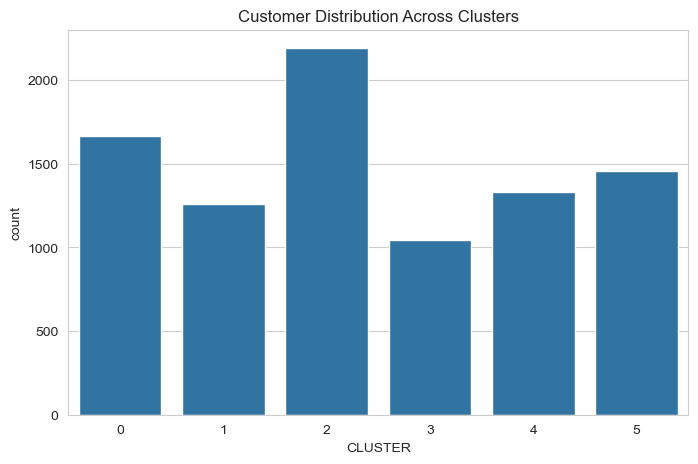

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    data=profile_df,
    x="CLUSTER"
)

plt.title("Customer Distribution Across Clusters")

plt.show()

The distribution indicates that all clusters contain a meaningful number of customers, suggesting that the selected six-cluster solution produces balanced customer segments rather than creating very small or unstable groups.

A balanced cluster structure improves the reliability and interpretability of the segmentation results.

## Credit Utilization Ratio by Cluster

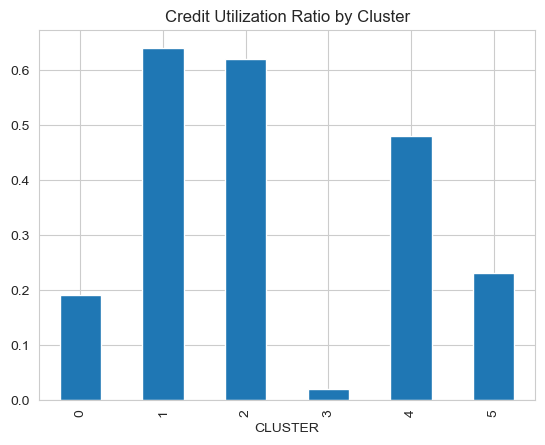

In [56]:
cluster_profile["UTILIZATION_RATIO"].plot(
    kind="bar"
)

plt.title("Credit Utilization Ratio by Cluster")
plt.show()

The utilization ratio measures the proportion of available credit being used by customers.

Clusters 1 and 2 have the highest utilization ratios, at approximately 0.64 and 0.62 respectively, indicating heavy dependence on available credit limits.

Cluster 3 has the lowest utilization ratio (0.02), suggesting minimal credit usage and very conservative spending behavior.

## Payment Ratio by Cluster

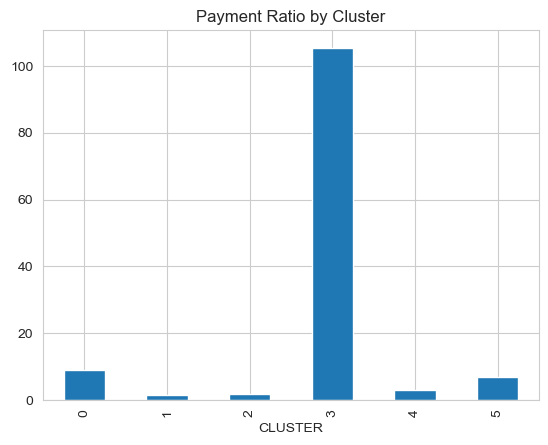

In [57]:
cluster_profile["PAYMENT_RATIO"].plot(
    kind="bar"
)

plt.title("Payment Ratio by Cluster")
plt.show()

The payment ratio measures the relationship between customer payments and outstanding balances.

Cluster 3 demonstrates the strongest repayment behavior with a payment ratio of 105.39, indicating that customers generally clear their balances whenever they use the card.

Clusters 1 and 2 show considerably lower payment ratios of 1.36 and 1.77 respectively, suggesting that balances are often carried forward rather than fully repaid.

## Average Purchase Value by Cluster

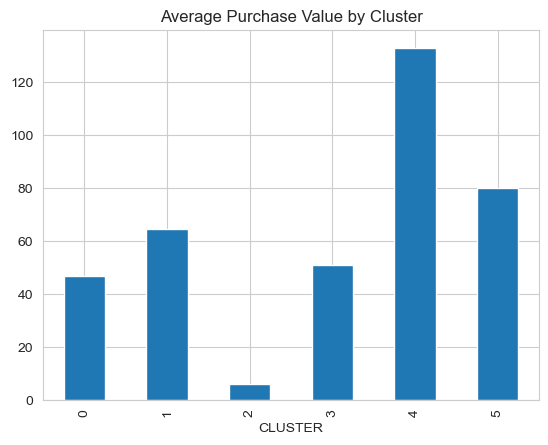

In [58]:
cluster_profile["AVG_PURCHASE_VALUE"].plot(
    kind="bar"
)

plt.title("Average Purchase Value by Cluster")
plt.show()

Average Purchase Value measures the typical amount spent per transaction.

Cluster 4 records the highest average purchase value at 133.05, indicating that customers in this segment tend to make fewer but larger purchases.

Cluster 2 records the lowest average purchase value at 5.97, reflecting minimal purchase activity.

# Key Insights

1. The customer base is highly diverse, with six distinct behavioral segments identified through clustering.

2. Cluster 5 (Premium High-Value Customers) represents the most valuable customer group, exhibiting the highest purchase volume (3294.46), transaction frequency (43.52), and credit limits (6843.57). These customers contribute significantly to overall business revenue.

3. Cluster 0 (Active Installment Shoppers) demonstrates healthy card usage patterns, characterized by frequent installment purchases, low credit utilization (0.19), and strong repayment behavior.

4. Clusters 1 and 2 represent the highest-risk customer groups. Both segments show high utilization ratios (0.64 and 0.62) and significant cash advance usage, indicating greater dependence on credit facilities.

5. Cluster 3 (Dormant Customers) shows minimal engagement with credit card services, maintaining the lowest balance (38.89) and utilization ratio (0.02). This segment presents an opportunity for customer reactivation initiatives.

6. Cluster 4 (High-Value One-Off Purchasers) exhibits the highest average purchase value (133.05), indicating a preference for occasional high-ticket purchases rather than frequent transactions.

7. The clustering analysis demonstrates that customer behavior is influenced not only by spending volume but also by repayment patterns, credit utilization, and cash advance dependency.

# Business Recommendations

## Cluster 0 – Active Installment Shoppers

- Promote installment-based offers and EMI schemes.
- Provide loyalty rewards for frequent purchases.
- Encourage higher spending through cashback programs.

## Cluster 1 – Heavy Credit Users

- Implement proactive credit risk monitoring.
- Offer balance transfer and debt consolidation products.
- Provide financial planning and budgeting assistance.
- Review credit limits periodically to manage risk exposure.

## Cluster 2 – Cash Advance Dependents

- Introduce lower-cost financing alternatives.
- Promote responsible credit usage through educational campaigns.
- Monitor delinquency risk closely.
- Offer structured repayment solutions when necessary.

## Cluster 3 – Dormant Customers

- Launch reactivation campaigns using targeted promotions.
- Offer welcome-back incentives and cashback rewards.
- Increase engagement through personalized communication.
- Encourage digital banking and card usage initiatives.

## Cluster 4 – High-Value One-Off Purchasers

- Partner with premium merchants and retailers.
- Offer travel, luxury, and lifestyle benefits.
- Promote seasonal campaigns focused on high-ticket purchases.
- Encourage increased transaction frequency through rewards.

## Cluster 5 – Premium High-Value Customers

- Introduce VIP loyalty programs.
- Provide exclusive rewards and premium card upgrades.
- Offer concierge services and personalized offers.
- Prioritize retention strategies to maximize customer lifetime value.

# Limitations

1. The clustering analysis was performed using historical customer behavior and may not fully capture future changes in spending patterns.

2. The dataset contains only credit card transaction and account-related information. Additional demographic, geographic, or income-related features could improve segmentation quality.

3. Although PCA helped reduce dimensionality and noise, some information loss may have occurred during the transformation process.

4. The Silhouette Score of the selected K-Means model (0.2208) indicates moderate cluster separation, suggesting that some overlap exists between customer segments.

5. Cluster interpretations are based on average values within each segment. Individual customer behavior may differ from the overall cluster characteristics.

6. The analysis assumes that customer behavior remains relatively stable over time. Significant economic or behavioral changes may require the model to be retrained.

7. The clustering results are sensitive to the available features and preprocessing choices. Different feature engineering strategies could potentially produce different customer segments.

# Conclusion

This project successfully applied unsupervised machine learning techniques to segment credit card customers into meaningful behavioral groups. After preprocessing, feature engineering, dimensionality reduction using PCA, and evaluating multiple clustering algorithms, K-Means with six clusters was selected as the final model based on its superior Silhouette Score (0.2208) and lowest Davies-Bouldin Index (1.5114).

The analysis identified six distinct customer segments, ranging from Premium High-Value Customers and Active Installment Shoppers to Heavy Credit Users, Cash Advance Dependents, and Dormant Customers. These segments reveal significant differences in spending habits, repayment behavior, credit utilization, and cash advance dependency.

The resulting segmentation provides actionable insights that can support targeted marketing, customer retention, personalized product offerings, and risk management strategies. By transforming raw transactional data into meaningful customer personas, the organization can make more informed business decisions and improve overall customer relationship management.